<a href="https://colab.research.google.com/github/Silas-Laar/PD-Telemonitoring/blob/main/PD_Telemonitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install umap-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import umap
import networkx as nx
from plotly.subplots import make_subplots
sns.set_theme(style="darkgrid", palette="husl")
px.defaults.template = "plotly_dark"
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
import pandas as pd

# lOADING THE DATASET
df = pd.read_csv('/content/parkinsons_updrs.data')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(5875, 22)
['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181 

In [7]:
# Selecting voice features and drop labels for unsupervised work
voice_features = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
                  'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11',
                  'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
df_voice = df[voice_features + ['subject#', 'test_time', 'age', 'sex']].copy()
print(df_voice.shape)

(5875, 20)


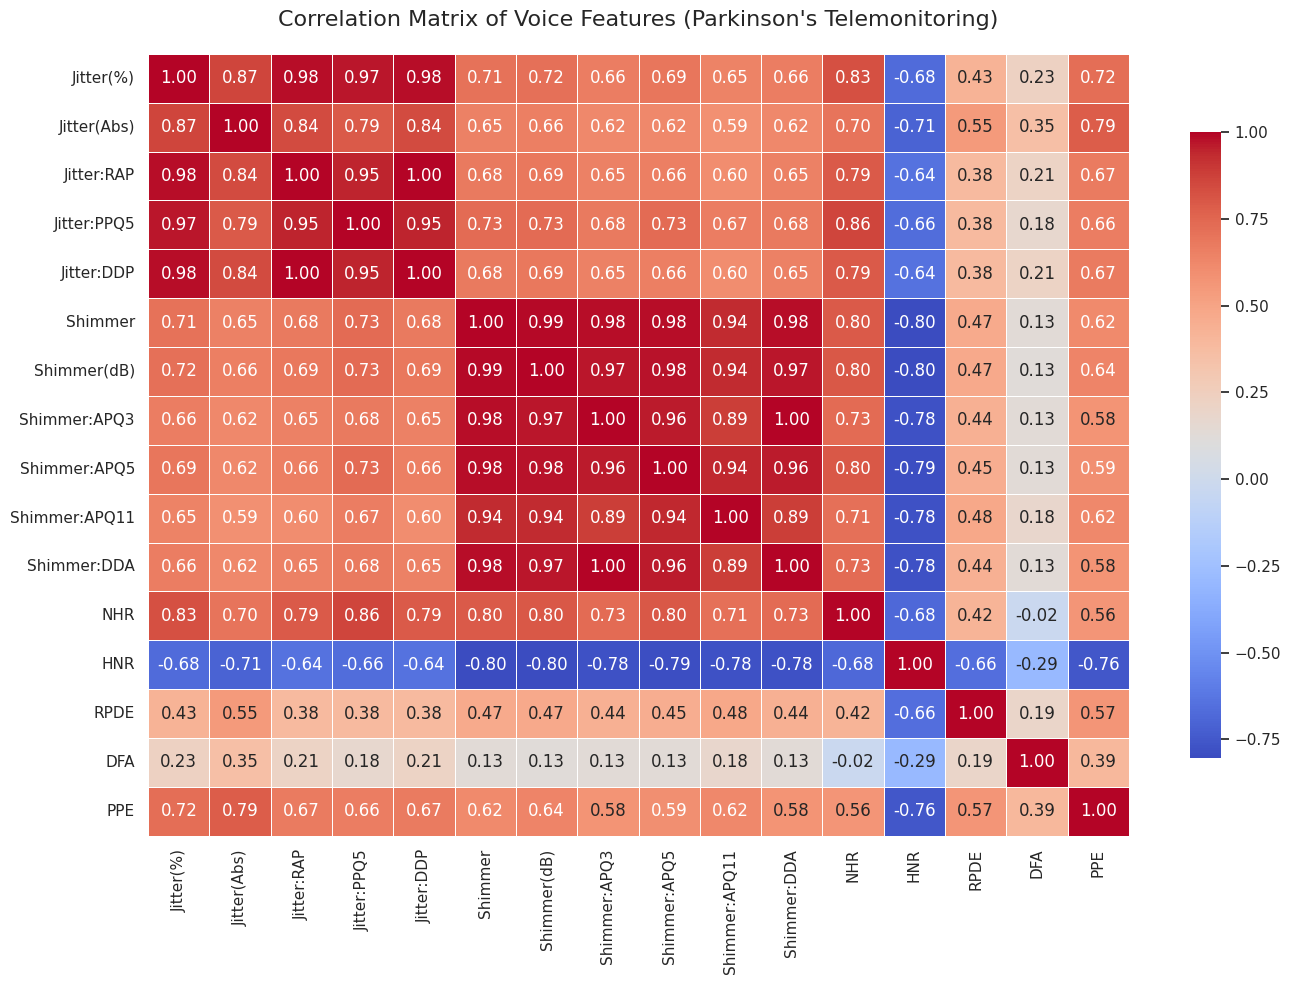

In [8]:
# correlation heatmap of voice features
plt.figure(figsize=(14, 10))
corr = df_voice[voice_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Voice Features (Parkinson's Telemonitoring)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [9]:
# Interactive trajectory plots for selected patients
sample_subjects = df_voice['subject#'].unique()[:6]
fig = px.line(df_voice[df_voice['subject#'].isin(sample_subjects)],
              x='test_time', y='HNR', color='subject#',
              title="HNR Trajectories Over Time for Sample Patients",
              labels={'HNR': 'Harmonics-to-Noise Ratio', 'test_time': 'Days since baseline'},
              template="plotly_dark", markers=True)
fig.update_layout(height=600, legend_title="Subject #")
fig.show()

In [10]:
# Scaling voice features and preparing data
scaler = StandardScaler()
df_voice_scaled = df_voice.copy()
df_voice_scaled[voice_features] = scaler.fit_transform(df_voice[voice_features])
print("Features scaled successfully.")

Features scaled successfully.


In [11]:
# Creating PyTorch Dataset for VAE
class VoiceDataset(Dataset):
    def __init__(self, data):
        self.X = torch.tensor(data[voice_features].values, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]
dataset = VoiceDataset(df_voice_scaled)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [12]:
class VAE(nn.Module):
    def __init__(self, input_dim=16, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("VAE model ready (latent_dim=8).")

VAE model ready (latent_dim=8).


In [13]:
# VAE Training Loop
def loss_function(recon_x, x, mu, logvar, beta=0.8):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss, kld_loss, recon_loss + beta * kld_loss

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.5, patience=25,
                                                 min_lr=1e-6)

epochs = 300
best_loss = float('inf')
patience = 50
patience_counter = 0

model.train()
print("Starting improved VAE training...\n")

for epoch in range(epochs):
    total_loss = 0.0
    total_recon = 0.0
    total_kld = 0.0

    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(batch)
        recon_loss, kld_loss, loss = loss_function(recon, batch, mu, logvar, beta=0.8)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kld += kld_loss.item()

    avg_loss = total_loss / len(dataloader)
    avg_recon = total_recon / len(dataloader)
    avg_kld = total_kld / len(dataloader)

    scheduler.step(avg_loss)

    # Print progress every 30 epochs
    if (epoch + 1) % 30 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{epochs} | Avg Loss: {avg_loss:.2f} | "
              f"Recon: {avg_recon:.2f} | KLD: {avg_kld:.2f} | LR: {current_lr:.6f}")

    # Early stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print(f"\nTraining completed!")
print(f"Best Average Loss: {best_loss:.2f}")
print("Lower reconstruction value = better voice feature learning.")

Starting improved VAE training...

Epoch   1/300 | Avg Loss: 1472.40 | Recon: 1325.98 | KLD: 183.03 | LR: 0.001000
Epoch  30/300 | Avg Loss: 526.82 | Recon: 292.34 | KLD: 293.10 | LR: 0.001000
Epoch  60/300 | Avg Loss: 511.83 | Recon: 272.74 | KLD: 298.86 | LR: 0.001000
Epoch  90/300 | Avg Loss: 507.93 | Recon: 266.53 | KLD: 301.76 | LR: 0.001000
Epoch 120/300 | Avg Loss: 496.13 | Recon: 255.84 | KLD: 300.36 | LR: 0.000500
Epoch 150/300 | Avg Loss: 497.46 | Recon: 257.76 | KLD: 299.62 | LR: 0.000500
Epoch 180/300 | Avg Loss: 495.92 | Recon: 253.61 | KLD: 302.90 | LR: 0.000250
Epoch 210/300 | Avg Loss: 493.25 | Recon: 250.98 | KLD: 302.83 | LR: 0.000125
Epoch 240/300 | Avg Loss: 491.19 | Recon: 251.80 | KLD: 299.24 | LR: 0.000125
Epoch 270/300 | Avg Loss: 489.26 | Recon: 248.18 | KLD: 301.35 | LR: 0.000125
Epoch 300/300 | Avg Loss: 490.33 | Recon: 250.14 | KLD: 300.24 | LR: 0.000063

Training completed!
Best Average Loss: 487.29
Lower reconstruction value = better voice feature learning

In [14]:
# Extract latent representations
model.eval()
latents = []
with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)
        _, mu, _ = model(batch)
        latents.append(mu.cpu().numpy())
latents = np.vstack(latents)
df_latent = pd.DataFrame(latents, columns=[f"latent_{i}" for i in range(latents.shape[1])])
df_latent = pd.concat([df_latent.reset_index(drop=True), df_voice[['subject#', 'test_time']].reset_index(drop=True)], axis=1)
print("Latent features extracted.")

Latent features extracted.


In [15]:
# 2D UMAP Visualization of latent space
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(latents)
df_latent['umap1'] = embedding[:, 0]
df_latent['umap2'] = embedding[:, 1]
fig = px.scatter(df_latent, x='umap1', y='umap2', color='test_time',
                 title="UMAP of VAE Latent Space (Colored by Test Time)",
                 labels={'test_time': 'Days since baseline'}, opacity=0.8,
                 color_continuous_scale=px.colors.sequential.Viridis)
fig.update_layout(height=700)
fig.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [16]:
# KMeans clustering on latent space + silhouette score
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(latents)
df_latent['cluster'] = clusters
sil_score = silhouette_score(latents, clusters)
print(f"Silhouette Score: {sil_score:.4f} (higher = better separation)")
fig = px.scatter(df_latent, x='umap1', y='umap2', color='cluster',
                 title=f"Latent Space Clusters (Silhouette: {sil_score:.3f})",
                 template="plotly_dark")
fig.show()

Silhouette Score: 0.2646 (higher = better separation)


In [17]:
# Patient Trajectory in latent space
fig = px.line(df_latent, x='test_time', y='latent_0', color='subject#',
              title="Latent Dimension 0 Trajectories per Patient",
              labels={'latent_0': 'Latent Dim 0'})
fig.update_layout(height=600)
fig.show()

In [18]:
# Building and visualizing patient similarity graph
G = nx.Graph()
for subj in df_latent['subject#'].unique()[:30]:
    sub = df_latent[df_latent['subject#'] == subj]
    avg_latent = sub[[f"latent_{i}" for i in range(8)]].mean().values
    G.add_node(subj, latent=avg_latent)
for i in list(G.nodes):
    for j in list(G.nodes):
        if i < j:
            sim = np.dot(G.nodes[i]['latent'], G.nodes[j]['latent']) / (np.linalg.norm(G.nodes[i]['latent']) * np.linalg.norm(G.nodes[j]['latent']) + 1e-8)
            if sim > 0.85:
                G.add_edge(i, j, weight=sim)
pos = nx.spring_layout(G, seed=42)
edge_x, edge_y, edge_weights = [], [], []
for edge in G.edges(data=True):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])
    edge_weights.append(edge[2]['weight'])
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]
fig = go.Figure()
fig.add_trace(go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=1, color='lightblue'), opacity=0.6))
fig.add_trace(go.Scatter(x=node_x, y=node_y, mode='markers+text', text=list(G.nodes()),
                         marker=dict(size=15, color='gold'), textposition="top center"))
fig.update_layout(title="Patient Similarity Graph (VAE Latents)", showlegend=False, height=700)
fig.show()

In [19]:
# Radar chart of cluster centroids
centroids = kmeans.cluster_centers_
fig = go.Figure()
for i, cent in enumerate(centroids):
    fig.add_trace(go.Scatterpolar(r=cent, theta=[f"Latent {j}" for j in range(8)],
                                  fill='toself', name=f"Cluster {i}"))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[-3, 3])),
                  title="Cluster Centroids in Latent Space (Radar Chart)")
fig.show()